### Build A Basic Chatbot With Langgraph (Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    '''
        Messages have the type list. The add_messages function in annotation 
        defines how this state key should be updated. 
        In this case, it appends messages to the list, rather than overwriting them
    '''
    messages: Annotated[list, add_messages]

In [22]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [44]:
from langchain.chat_models import init_chat_model

llm_groq = init_chat_model("groq:qwen/qwen3-32b")
llm_google = init_chat_model("google_genai:gemini-2.5-flash-lite")

In [13]:
llm_groq

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3 8B', 'status': 'deprecated', 'release_date': '2024-04-18', 'last_updated': '2024-04-18', 'open_weights': True, 'max_input_tokens': 8192, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002A84311CE10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002A84311D310>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [14]:
llm_google

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11', 'langchain-google-genai': '4.2.6'}}, output_version=None, profile={'name': 'Gemini 2.5 Flash-Lite', 'release_date': '2025-06-17', 'last_updated': '2025-06-17', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash-lite', client=<google.genai.client.Client object at 0x000002A84311D450>, default_metadata=(), model_kwargs={})

In [15]:
# node functionality
def chatbot(state: State):
    return {"messages": [llm_google.invoke(state["messages"])]}

In [16]:
graph_builder = StateGraph(State)

# adding node
graph_builder.add_node("llmchatbot", chatbot)
# adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# compile the graph
graph = graph_builder.compile()

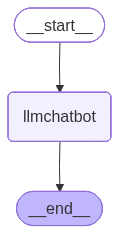

In [17]:
# visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Error occurred: ", e)

In [ ]:
response = graph.invoke({"messages": "hi"})

In [19]:
response["messages"][-1].content

'Hi there! How can I help you today?'

In [20]:
for event in graph.stream({"messages": "Hi How are you ?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hi there! I'm doing well, thank you for asking. I'm a large language model, trained by Google, so I don't experience feelings in the same way humans do, but I'm functioning optimally and ready to assist you.

How are *you* doing today? Is there anything I can help you with?


#### Chatbot with Tool

In [23]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the naviga

In [24]:
# Custom Function
def multiply(a: int, b: int) -> int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [25]:
tools =[tool, multiply]
llm_with_tools = llm_google.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11', 'langchain-google-genai': '4.2.6'}}, output_version=None, profile={'name': 'Gemini 2.5 Flash-Lite', 'release_date': '2025-06-17', 'last_updated': '2025-06-17', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash-lite', client=<google.genai.client.Client object at 0x000002A84311D450>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'

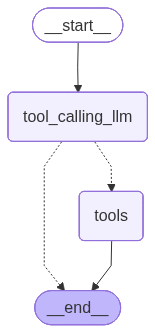

In [26]:
from langgraph.prebuilt import ToolNode, tools_condition

# node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if latest message from assistant is a tool call -> tools_condition routes to tools
    # if latest message from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

# compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
response = graph.invoke({"messages": "What is the recent ai news ?"})

In [28]:
response["messages"][-1].content

'{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.rcrwireless.com/20260702/network-infrastructure/telco-agents-smash-hits", "title": "Wednesday | Telco agents and smash hits (editorial commentary) - RCR Wireless News", "score": 0.6854659, "published_date": "Thu, 02 Jul 2026 11:38:41 GMT", "content": "*From the newsletter: AI agents in telecoms is sharpening focus on governance, controlled autonomy and human oversight, while momentum in private 5G and industrial AI continues to build through new deployments, ecosystem partnerships, spectrum initiatives and innovative network applications.*. Twelve months ago, *RCR* might have covered these items individually, in depth, but AI has changed everything, including the news trade and news beat (*so share if you care).* For one, Nokia – which we shall call ECE for now, on the grounds Nokia has put it up for sale, and doesn’t deserve the credit – has started its own little PR engin

In [29]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news ?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (23510a56-1783-42bf-9315-3dd6626e61b4)
 Call ID: 23510a56-1783-42bf-9315-3dd6626e61b4
  Args:
    query: AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.rcrwireless.com/20260702/network-infrastructure/telco-agents-smash-hits", "title": "Wednesday | Telco agents and smash hits (editorial commentary) - RCR Wireless News", "score": 0.6854659, "published_date": "Thu, 02 Jul 2026 11:38:41 GMT", "content": "*From the newsletter: AI agents in telecoms is sharpening focus on governance, controlled autonomy and human oversight, while momentum in private 5G and industrial 

In [30]:
response = graph.invoke({"messages": "what is 5 muliplied by 4"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 5 muliplied by 4
================================== Ai Message ==================================
Tool Calls:
  multiply (6339c887-3f58-4637-a816-3ab8b6dc67ca)
 Call ID: 6339c887-3f58-4637-a816-3ab8b6dc67ca
  Args:
    a: 5
    b: 4
================================= Tool Message =================================
Name: multiply

20


In [32]:
response = graph.invoke({"messages": "give me recent ai news and then what is 5 muliplied by 4"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me recent ai news and then what is 5 muliplied by 4
================================== Ai Message ==================================
Tool Calls:
  tavily_search (7ccca828-b598-4e34-ad35-a094c7ca7e2c)
 Call ID: 7ccca828-b598-4e34-ad35-a094c7ca7e2c
  Args:
    time_range: day
    topic: news
    query: AI news
  multiply (6ae73f06-abc2-42bc-b3f5-c90756d40117)
 Call ID: 6ae73f06-abc2-42bc-b3f5-c90756d40117
  Args:
    a: 5
    b: 4
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.rcrwireless.com/20260702/network-infrastructure/telco-agents-smash-hits", "title": "Wednesday | Telco agents and smash hits (editorial commentary) - RCR Wireless News", "score": 0.6854659, "published_date": "Thu, 02 Jul 2026 11:38:41 GMT", "content": "*From the new

#### ReAct Agent Architecture

In above agent , we can see that from tool node we are moving to end node also, so it may be possible that after response from one tool this workflow will move to END state and will not answer the other tools results (if query required multiple tool calls). So to tackle this we can update the graph flow and after tool we can again move to llm_node and then from that node we will end the workflow.

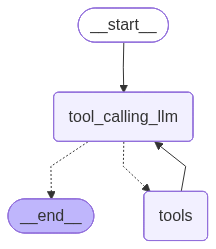

In [33]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if latest message from assistant is a tool call -> tools_condition routes to tools
    # if latest message from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

# compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
response = graph.invoke({"messages": "Give me recent news about fifa worldcup and then multiply 34 and 12"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me recent news about fifa worldcup and then multiply 34 and 12
================================== Ai Message ==================================
Tool Calls:
  tavily_search (864e0efe-d7bc-46c1-9fa4-cc38032b7587)
 Call ID: 864e0efe-d7bc-46c1-9fa4-cc38032b7587
  Args:
    query: fifa worldcup
    time_range: day
    topic: news
  multiply (6c6d9941-861e-44b4-b3d2-a9061b8c9a79)
 Call ID: 6c6d9941-861e-44b4-b3d2-a9061b8c9a79
  Args:
    b: 12
    a: 34
================================= Tool Message =================================
Name: tavily_search

{"query": "fifa worldcup", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.espn.com/soccer/story/_/id/49247275/liverpool-confirm-appointment-andoni-iraola-coaching-staff", "title": "Liverpool confirm appointment of Andoni Iraola coaching staff - ESPN", "score": 0.37490568, "published_date": "Thu, 02 Jul 2026 12:46

#### Adding Memory in Agentic Graph

In [35]:
response = graph.invoke({"messages": "Hello my name is Arrow"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Arrow
================================== Ai Message ==================================

Hi Arrow, it's nice to meet you! How can I help you today?


In [36]:
response = graph.invoke({"messages": "what is my name?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

I do not have access to personal information, so I cannot tell you what your name is.


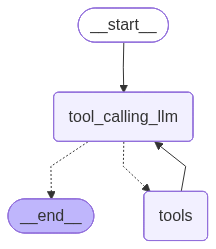

In [45]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

tools =[tool, multiply]
groq_llm_with_tools = llm_groq.bind_tools(tools)

# node definition
def tool_calling_llm(state: State):
    return {"messages": [groq_llm_with_tools.invoke(state["messages"])]}

# graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if latest message from assistant is a tool call -> tools_condition routes to tools
    # if latest message from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

# compile the graph
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": "Hi my name is Arrow"}, config=config)
response

{'messages': [HumanMessage(content='Hi my name is Arrow', additional_kwargs={}, response_metadata={}, id='cabac3f9-59c7-4100-b090-0a9f6fe02ddf'),
  AIMessage(content='Hello Arrow! How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user said, "Hi my name is Arrow." Let me think about how to respond.\n\nFirst, I need to acknowledge their greeting. Since they introduced themselves as Arrow, I should use their name in the response to make it friendly. The tools provided include a search function and a multiply function. But the user hasn\'t asked for anything specific yet. They might just be testing the water or looking for a conversation.\n\nI should check if there\'s any need to call a function here. The user didn\'t ask a question that requires searching or multiplying. So probably no function call is needed. Just a polite response to their introduction. Let me make sure I don\'t miss any hidden requests. They might have mentioned something else, but it\'s 

In [47]:
response["messages"][-1].content

'Hello Arrow! How can I assist you today?'

In [48]:
response = graph.invoke({"messages": "Hey what is my name ?"}, config=config)
response["messages"][-1].content

'Your name is Arrow! You mentioned it earlier. 😊 How else can I assist you?'

In [50]:
response = graph.invoke({"messages": "Do you remember my name"}, config=config)
response["messages"][-1].content

'Yes, you mentioned earlier that your name is **Arrow**. Since this conversation is anonymous and I don’t retain personal data beyond our current interaction, I can only reference information you’ve shared directly. How can I assist you further? 😊'

In [51]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Arrow
================================== Ai Message ==================================

Hello Arrow! How can I assist you today?
================================ Human Message =================================

Hey what is my name ?
================================== Ai Message ==================================

Your name is Arrow! You mentioned it earlier. 😊 How else can I assist you?
================================ Human Message =================================

Do you have any information related to me
================================== Ai Message ==================================

I don't have access to personal information about users beyond what's shared in our current conversation. However, I can help you search for general information using tools like **tavily_search** if you'd like to explore topics related to your name (though I don't store personal data). How would you like to

#### Streaming

In [52]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [62]:
def superbot(state: State):
    return {"messages": [llm_groq.invoke(state['messages'])]}

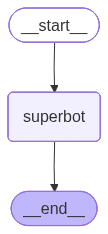

In [63]:
graph = StateGraph(State)

# node
graph.add_node("superbot",  superbot)

# edge
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile(checkpointer=memory)

# display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [64]:
# invocation
config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({"messages": "Hi my name is Arrow and I like cricket"}, config)

{'messages': [HumanMessage(content='Hi my name is Arrow and I like cricket', additional_kwargs={}, response_metadata={}, id='6436a1ac-e844-46bc-b306-a0a603c054cd'),
  HumanMessage(content='Hi my name is Arrow and I like cricket', additional_kwargs={}, response_metadata={}, id='79edfe1e-93a7-4cda-aabf-b8396a442991'),
  HumanMessage(content='Hi my name is Arrow and I like cricket', additional_kwargs={}, response_metadata={}, id='587b90e7-75a0-49cb-aee2-5d08eae3e6f9'),
  HumanMessage(content='Hi my name is Arrow and I like cricket', additional_kwargs={}, response_metadata={}, id='4b95c454-b23c-4d4d-911f-c34082e38ee0'),
  AIMessage(content='<think>\nOkay, so Arrow has said "Hi my name is Arrow and I like cricket" three times now. Let me try to figure out what\'s going on here. \n\nFirst, the user might be testing if the AI is paying attention or if there\'s a repetition issue. Maybe they want to see if the response changes each time. But since I gave the same response each time, maybe they

Methods: .stream() and .astream()
These methods are sync and async methods for streaming back results
Additional parameters is streaming nodes of graph state
- values: this streams the full state of graph after each node is called
- updates: this streams updates the state of graph after each node is called

In [65]:
# create a thread
config = {"configurable": {"thread_id": "3"}}
for chunk in graph_builder.stream({"messages": "hi my name is arrow and i like cricket"}, config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced themselves as Arrow and mentioned they like cricket. I need to respond in a friendly and engaging way. Let's start by acknowledging their name and interest. Cricket is a popular sport, so maybe ask them about their favorite aspects of the game. Do they play it, watch it, or follow a particular team? Also, maybe ask if they have any favorite players or memorable matches. Keeping the conversation open-ended will encourage them to share more. I should make sure the tone is positive and supportive. Let me put that together in a natural, conversational way without any markdown.\n</think>\n\nHi Arrow! Nice to meet you! 🏏 Cricket is an amazing sport—whether you're into playing it, watching it, or following your favorite team, there's always something exciting happening. Do you have a favorite part about cricket? Maybe a particular format like Test matches, ODIs, or T20s? Or perhaps a favorite player or team? I'd 

In [66]:
for chunk in graph_builder.stream({"messages": "hi my name is arrow and i like cricket"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi my name is arrow and i like cricket', additional_kwargs={}, response_metadata={}, id='1682340d-3180-4df2-8666-e6d6faf56263'), AIMessage(content="<think>\nOkay, the user introduced themselves as Arrow and mentioned they like cricket. I need to respond in a friendly and engaging way. Let's start by acknowledging their name and interest. Cricket is a popular sport, so maybe ask them about their favorite aspects of the game. Do they play it, watch it, or follow a particular team? Also, maybe ask if they have any favorite players or memorable matches. Keeping the conversation open-ended will encourage them to share more. I should make sure the tone is positive and supportive. Let me put that together in a natural, conversational way without any markdown.\n</think>\n\nHi Arrow! Nice to meet you! 🏏 Cricket is an amazing sport—whether you're into playing it, watching it, or following your favorite team, there's always something exciting happening. Do you 

In [67]:
# create a thread
config = {"configurable": {"thread_id": "4"}}
for chunk in graph_builder.stream({"messages": "hi my name is arrow and i like cricket"}, config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="<think>\nOkay, the user is named Arrow and they like cricket. I need to respond in a friendly and engaging way. Let me start by greeting them and acknowledging their name. Since they mentioned cricket, maybe ask them about their favorite teams or players. Also, maybe ask if they play cricket or just follow it. Keep the tone positive and open-ended to encourage more conversation. Let me check if there's anything else they might want to share. Oh, maybe mention the current season or any upcoming matches if relevant. But I shouldn't assume too much, so maybe just a general question. Alright, let me put that together.\n</think>\n\nHi Arrow! Nice to meet you 😊 Cricket is an amazing sport—do you follow a particular team or player closely? Or do you play the game yourself? I'd love to hear more about what you enjoy most about it! 🏏", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 180, 'prompt_tokens': 17, 'total_toke

In [68]:
for chunk in graph_builder.stream({"messages": "i also like football"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi my name is arrow and i like cricket', additional_kwargs={}, response_metadata={}, id='2d71671b-fa96-414a-a9df-2300399eaad2'), AIMessage(content="<think>\nOkay, the user is named Arrow and they like cricket. I need to respond in a friendly and engaging way. Let me start by greeting them and acknowledging their name. Since they mentioned cricket, maybe ask them about their favorite teams or players. Also, maybe ask if they play cricket or just follow it. Keep the tone positive and open-ended to encourage more conversation. Let me check if there's anything else they might want to share. Oh, maybe mention the current season or any upcoming matches if relevant. But I shouldn't assume too much, so maybe just a general question. Alright, let me put that together.\n</think>\n\nHi Arrow! Nice to meet you 😊 Cricket is an amazing sport—do you follow a particular team or player closely? Or do you play the game yourself? I'd love to hear more about what you en

In [69]:
config = {"configurable": {"thread_id": "5"}}
async for event in graph_builder.astream_events({"messages": ["Hi my name is arrow and i like to play cricket"]}, config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi my name is arrow and i like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f2450-e74f-7361-bb15-d88df047be3f', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi my name is arrow and i like to play cricket', additional_kwargs={}, response_metadata={}, id='82752688-76fb-4bc1-a6d0-1436dc8a141e')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019f2450-e900-7ae0-9f8a-ce3b4c986fc2', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:a378a996-ac41-12cf-44c2-952212036847'}, 'parent_ids': ['019f2450-e74f-7361-bb15-d88df047be3f']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':